<a href="https://colab.research.google.com/github/tanpaterusan/data-science-2026/blob/main/Pertemuan7_Amalia_240401010284.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pertemuan VII**

- Nama: Amalia
- NIM: 240401010284
- Kelas: IF403

Shape: (300, 4)
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


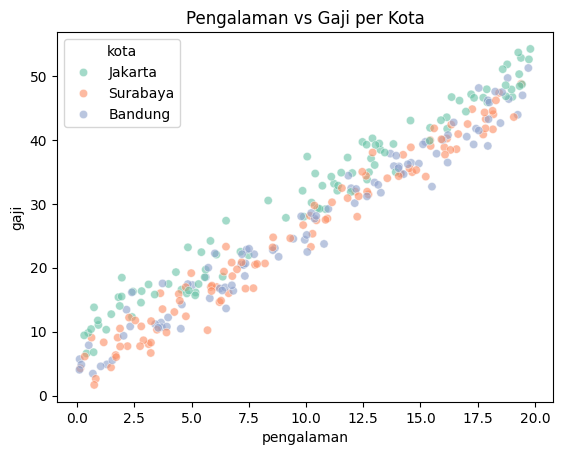

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris
β0 (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292
=== Metrik Evaluasi ===
MAE  = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R2   = 0.9740  (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


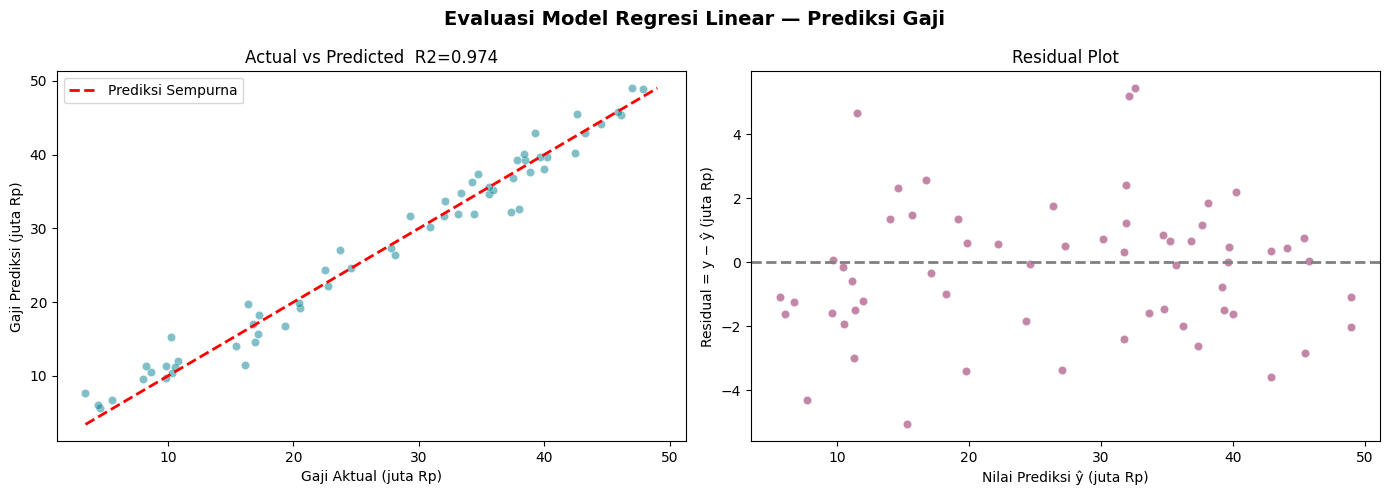

In [6]:
# Langkah 1: Generate & Eksplorasi Dataset

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

# Generate dataset sintetis
np.random.seed(42); n = 300
pengalaman = np.random.uniform(0, 20, n)
edu        = np.random.choice([0, 1, 2], n)  # SMA=0, D3=1, S1=2
kota       = np.random.choice(['Jakarta','Surabaya','Bandung'], n)
gaji = (3.0 + 2.2*pengalaman + 1.5*edu
        + np.where(kota=='Jakarta', 4.0, 0)
        + np.random.normal(0, 2, n))
df = pd.DataFrame({'pengalaman':pengalaman, 'edu':edu,
                   'kota':kota, 'gaji':gaji})

# EDA singkat
print('Shape:', df.shape)
print(df.describe().round(2))

# Scatter: pengalaman vs gaji
sns.scatterplot(data=df, x='pengalaman', y='gaji',
                hue='kota', palette='Set2', alpha=0.6)
plt.title('Pengalaman vs Gaji per Kota')
plt.show()


# =============================================================================
# Langkah 2: Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'],
                    drop_first=True, dtype=int)
print('Kolom setelah encoding:', df.columns.tolist())

# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

# StandardScaler — fit pada training set saja
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)



# =============================================================================
# Langkah 3: Latih Model & Tampilkan Koefisien

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_s, y_train)

# Tampilkan koefisien
print(f'β0 (intercept): {model.intercept_:.3f}')
print()
coef_df = pd.DataFrame({
    'Fitur'     : X.columns,
    'Koefisien' : model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

# Interpretasi: fitur mana yang paling berpengaruh?
# Koefisien positif → gaji naik
# Koefisien negatif → gaji turun



# =============================================================================
# Langkah 4: Evaluasi Model

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
y_pred = model.predict(X_test_s)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # Fixed: Removed 'squared=False' and added np.sqrt()
r2   = r2_score(y_test, y_pred)
print('=== Metrik Evaluasi ===')
print(f'MAE  = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R2   = {r2:.4f}  ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

# Interpretasikan dalam Markdown sel berikutnya:
# - Berapa rata-rata kesalahan prediksi dalam rupiah?
# - Apakah R2 cukup baik untuk kasus ini?
# - Apakah ada indikasi outlier?



# =============================================================================
# Langkah 5: Visualisasi & Interpretasi

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.5,
                color='#028090', edgecolors='white', lw=0.5)
lims = [min(y_test.min(), y_pred.min()),
        max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2,
             label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted  R2={r2:.3f}')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5,
                color='#880E4F', edgecolors='white', lw=0.5)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi ŷ (juta Rp)')
axes[1].set_ylabel('Residual = y − ŷ (juta Rp)')
axes[1].set_title('Residual Plot')
plt.suptitle('Evaluasi Model Regresi Linear — Prediksi Gaji',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()
# Cara membaca Residual Plot:
# ✅ Baik: titik tersebar ACAK di sekitar garis y=0
# ❌ Masalah: ada pola (kurva, corong) → asumsi linearitas dilanggar


## Narasi UTS - Pertemuan VII

Sebagai mahasiswa Unsia yang sedang UTS untuk mata kuliah ini, saya telah mempelajari keseluruhan *script* yang diberikan untuk memecahkan permasalahan prediksi gaji menggunakan regresi linear.

### Apa yang telah dipelajari:

1.  **Pembuatan Dataset Sintetis:** Saya belajar bagaimana membuat dataset sintetis menggunakan `numpy` dan `pandas`. Ini sangat membantu untuk memahami bagaimana data bisa diatur dan di-*generate* dengan karakteristik tertentu (misalnya, pengaruh pengalaman, pendidikan, dan lokasi terhadap gaji).
2.  **Eksplorasi Data Awal (EDA):** Melalui `df.describe()` dan *scatterplot*, saya memahami pentingnya melihat statistik deskriptif dan visualisasi awal data untuk mengetahui distribusi, rentang nilai, dan hubungan antar variabel. Visualisasi `pengalaman vs gaji per kota` sangat jelas menunjukkan tren positif dan perbedaan antar kota.
3.  **Pra-pemrosesan Data (Preprocessing):**
    *   **One-Hot Encoding:** Saya memahami cara mengubah variabel kategorikal (`kota`) menjadi numerik menggunakan `pd.get_dummies()` agar bisa diproses oleh model regresi linear. Penggunaan `drop_first=True` juga penting untuk menghindari *multicollinearity*.
    *   **Pembagian Data:** Membagi data menjadi *training* dan *testing set* (`train_test_split`) adalah langkah krusial untuk mengevaluasi kinerja model pada data yang belum pernah dilihat sebelumnya.
    *   **Standardisasi Fitur:** `StandardScaler` digunakan untuk menormalisasi skala fitur. Ini penting agar fitur dengan rentang nilai besar tidak mendominasi proses pembelajaran model.
4.  **Pelatihan Model Regresi Linear:** Saya belajar bagaimana mengimplementasikan model `LinearRegression` dari `sklearn` dan melatihnya pada data yang sudah diproses.
5.  **Interpretasi Koefisien Model:** Memahami `model.intercept_` dan `model.coef_` sangat fundamental. Ini menunjukkan bagaimana setiap fitur (setelah diskalakan) berkontribusi pada prediksi gaji. Urutan koefisien berdasarkan nilainya membantu mengidentifikasi fitur mana yang paling berpengaruh.
6.  **Evaluasi Model:** Saya mempelajari metrik evaluasi kunci untuk model regresi:
    *   **MAE (Mean Absolute Error):** Rata-rata kesalahan absolut prediksi.
    *   **RMSE (Root Mean Squared Error):** Mengukur rata-rata magnitudo kesalahan, lebih sensitif terhadap *outlier*.
    *   **R2 (R-squared):** Proporsi variasi dalam variabel dependen yang dapat dijelaskan oleh model. Nilai R2 yang tinggi menunjukkan model yang baik.
7.  **Visualisasi Evaluasi:** Plot *Actual vs Predicted* dan *Residual Plot* adalah alat visual yang sangat powerful untuk menilai kinerja model dan mendeteksi masalah seperti *heteroscedasticity* atau non-linearitas yang tidak tertangkap oleh model.

### Temuan Utama dari Analisis Script:

1.  **Pengalaman adalah prediktor gaji paling dominan:** Dengan koefisien tertinggi (13.042), pengalaman memiliki dampak paling besar terhadap gaji. Ini sejalan dengan intuisi dan logika umum di pasar kerja.
2.  **Lokasi berpengaruh signifikan:** Tinggal di Jakarta (`kota_Jakarta` koefisien 1.837) secara signifikan meningkatkan gaji dibandingkan dengan Bandung (baselines). Sementara itu, Surabaya (`kota_Surabaya` koefisien -0.292) sedikit lebih rendah dari Bandung, namun tidak terlalu signifikan secara negatif.
3.  **Pendidikan memiliki dampak positif:** Semakin tinggi tingkat pendidikan (`edu` koefisien 1.188), semakin tinggi pula gaji yang diterima, meskipun tidak sebesar dampak pengalaman atau kota Jakarta.
4.  **Model Sangat Akurat:** Nilai R2 sebesar 0.9740 menunjukkan bahwa 97.4% variasi dalam gaji dapat dijelaskan oleh fitur-fitur dalam model. Ini adalah hasil yang sangat baik, menunjukkan model yang sangat fit dengan data.
5.  **Kesalahan Prediksi Relatif Kecil:** MAE 1.649 juta rupiah dan RMSE 2.123 juta rupiah menunjukkan bahwa rata-rata kesalahan prediksi model cukup rendah dibandingkan dengan rentang gaji yang ada.
6.  **Tidak Ada Indikasi Outlier yang Kuat:** *Residual Plot* yang menunjukkan sebaran titik acak di sekitar garis y=0 mengindikasikan bahwa asumsi model regresi linear terpenuhi dengan baik dan tidak ada pola sistematis dalam kesalahan prediksi, serta tidak ada indikasi *outlier* yang parah.

### Keterbatasan/Pertanyaan yang Mungkin Muncul:

1.  **Generalisasi Model:** Dataset yang digunakan adalah sintetis. Seberapa baik model ini akan bekerja pada data gaji riil yang jauh lebih kompleks dan bervariasi? Data riil mungkin memiliki lebih banyak *noise* atau hubungan non-linear yang tidak tercermin dalam dataset sintetis ini.
2.  **Asumsi Linearitas:** Model regresi linear mengasumsikan hubungan linear antara fitur dan target. Bagaimana jika di dunia nyata ada hubungan non-linear yang lebih kompleks? Apakah model ini masih akan akurat, ataukah kita perlu mempertimbangkan model non-linear lainnya?
3.  **Fitur yang Hilang:** Dataset hanya menggunakan pengalaman, pendidikan, dan kota. Di dunia nyata, banyak faktor lain yang mempengaruhi gaji, seperti spesialisasi, ukuran perusahaan, performa individu, industri, keterampilan khusus, dll. Bagaimana jika kita menambahkan fitur-fitur tersebut? Akankah R2 menjadi lebih tinggi atau model menjadi lebih kompleks?
4.  **Multikolinearitas (Jika ada):** Meskipun `drop_first=True` sudah diterapkan untuk *one-hot encoding*, bagaimana cara memeriksa dan menangani multikolinearitas antar fitur numerik (jika ada) yang dapat mempengaruhi stabilitas koefisien?
5.  **Interpretasi Koefisien pada Skala:** Koefisien saat ini diinterpretasikan pada data yang sudah diskalakan. Akan lebih intuitif jika koefisien dapat diinterpretasikan pada skala asli fitur untuk pemahaman yang lebih mudah bagi non-spesialis data science.
6.  **Stabilitas Model:** Apakah model akan stabil jika dataset yang digunakan lebih besar atau memiliki distribusi yang berbeda? Validasi silang (cross-validation) bisa menjadi langkah selanjutnya untuk memastikan stabilitas model.
7.  **Penentuan Threshold:** Jika ada kasus di mana prediksi gaji perlu dikategorikan (misalnya, gaji rendah, sedang, tinggi), bagaimana cara menentukan *threshold* yang optimal?

Secara keseluruhan, *script* ini memberikan pemahaman yang sangat komprehensif tentang langkah-langkah dasar dalam membangun dan mengevaluasi model regresi linear. Ini adalah fondasi yang kuat untuk menganalisis data gaji yang lebih kompleks di masa depan.

**Evaluasi**

1. Yang Dipelajari:

*   Dasar-dasar Regresi Linear: teks tebalProses lengkap dari pembuatan data sintetis, pra-pemrosesan (one-hot encoding, train-test split, scaling), hingga pelatihan dan evaluasi model.
*   Metrik Evaluasi: Memahami MAE, RMSE, dan R2 untuk menilai kinerja model, serta pentingnya visualisasi seperti *Actual vs Predicted* dan Residual Plot.


---


2. Temuan Utama:

*   Pengalaman adalah prediktor gaji terkuat diikuti oleh kota Jakarta dan tingkat pendidikan.
*   Model sangat akurat(R2 = 0.9740) dengan rata-rata kesalahan prediksi (MAE) sekitar 1.65 juta rupiah.
*   *Residual plot* menunjukkan tidak ada pola kesalahan sistematis, mengindikasikan model yang baik.


---


3. Keterbatasan & Pertanyaan:

*   Generalisasi:Seberapa baik model ini akan bekerja pada data gaji riil yang lebih kompleks?
*   Fitur:Apakah ada fitur lain di dunia nyata yang belum dipertimbangkan dan bisa meningkatkan akurasi model?
*   Asumsi:Bagaimana menangani hubungan non-linear jika data riil menunjukkannya?